In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
import os
import fiona

In [2]:
fire_data = gpd.read_file("../total_fire.geojson")
ain_data = gpd.read_file("../datasets_par_departement/departement-01-ain-original.geojson")
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
yvelines_data = gpd.read_file("../datasets_par_departement/departement-78-yvelines-original.geojson")

In [3]:
ain_data.head()

,hex_id,raison_sortie,date_debut,date_fin,label,year,date,departement,duree_minutes,geometry
0,871f91c4dffffff,NATURELS,2018-01-05 17:41:19,2018-01-05 18:45:21,1.0,2018.0,2018-01-05,departement-01-ain,64,"POLYGON ((5.39217 46.12447, 5.39416 46.11236, ..."
1,871f91c6effffff,NATURELS,2018-01-06 17:56:49,2018-01-06 19:37:07,1.0,2018.0,2018-01-06,departement-01-ain,100,"POLYGON ((5.32470 46.15261, 5.32670 46.14050, ..."
2,871f910d6ffffff,NATURELS,2018-01-12 08:43:15,2018-01-12 09:36:25,1.0,2018.0,2018-01-12,departement-01-ain,53,"POLYGON ((5.68525 45.86548, 5.68720 45.85332, ..."
3,871f91c9bffffff,NATURELS,2018-01-15 17:55:58,2018-01-15 18:59:14,1.0,2018.0,2018-01-15,departement-01-ain,63,"POLYGON ((5.04235 45.87305, 5.04438 45.86093, ..."
4,871f910e3ffffff,NATURELS,2018-01-19 22:57:16,2018-01-20 00:21:51,1.0,2018.0,2018-01-19,departement-01-ain,84,"POLYGON ((5.76585 45.95039, 5.76778 45.93823, ..."


In [4]:
ain_data.columns

Index(['hex_id', 'raison_sortie', 'date_debut', 'date_fin', 'label', 'year',
       'date', 'departement', 'duree_minutes', 'geometry'],
      dtype='object')

In [10]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

In [11]:
fire_data = calculer_duree(fire_data, 'date_debut', 'date_fin')
fire_data['centroid'] = fire_data.geometry.centroid
fire_data['centroid_lon'] = fire_data['centroid'].x
fire_data['centroid_lat'] = fire_data['centroid'].y
fire_data['date_debut'] = pd.to_datetime(fire_data['date_debut'], errors='coerce')
fire_data['hour'] = fire_data['date_debut'].dt.hour
fire_data['date'] = pd.to_datetime(fire_data['date'], errors='coerce')
fire_data['month'] = fire_data['date'].dt.month
fire_data['duree'] = pd.to_timedelta(fire_data['duree'], errors='coerce')
fire_data['duree_minutes'] = fire_data['duree'].dt.total_seconds() / 60
fire_data['weekday'] = fire_data['date'].dt.weekday
fire_data['season'] = fire_data['month'].apply(season_encoding)
fire_data[['hour_sin', 'hour_cos']] = cyclical_encoding(fire_data['hour'], 24)
fire_data[['month_sin', 'month_cos']] = cyclical_encoding(fire_data['month'], 12)
fire_data[['weekday_sin', 'weekday_cos']] = cyclical_encoding(fire_data['weekday'], 7)

doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['season'] = doubs_data['month'].apply(season_encoding)
doubs_data[['hour_sin', 'hour_cos']] = cyclical_encoding(doubs_data['hour'], 24)
doubs_data[['month_sin', 'month_cos']] = cyclical_encoding(doubs_data['month'], 12)
doubs_data[['weekday_sin', 'weekday_cos']] = cyclical_encoding(doubs_data['weekday'], 7)

ain_data = calculer_duree(ain_data, 'date_debut', 'date_fin')
ain_data['centroid'] = ain_data.geometry.centroid
ain_data['centroid_lon'] = ain_data['centroid'].x
ain_data['centroid_lat'] = ain_data['centroid'].y
ain_data['date_debut'] = pd.to_datetime(ain_data['date_debut'], errors='coerce')
ain_data['hour'] = ain_data['date_debut'].dt.hour
ain_data['date'] = pd.to_datetime(ain_data['date'], errors='coerce')
ain_data['month'] = ain_data['date'].dt.month
ain_data['weekday'] = ain_data['date'].dt.weekday
ain_data['season'] = ain_data['month'].apply(season_encoding)
ain_data[['hour_sin', 'hour_cos']] = cyclical_encoding(ain_data['hour'], 24)
ain_data[['month_sin', 'month_cos']] = cyclical_encoding(ain_data['month'], 12)
ain_data[['weekday_sin', 'weekday_cos']] = cyclical_encoding(ain_data['weekday'], 7)

yvelines_data = calculer_duree(yvelines_data, 'date_debut', 'date_fin')
yvelines_data['centroid'] = yvelines_data.geometry.centroid
yvelines_data['centroid_lon'] = yvelines_data['centroid'].x
yvelines_data['centroid_lat'] = yvelines_data['centroid'].y
yvelines_data['date_debut'] = pd.to_datetime(yvelines_data['date_debut'], errors='coerce')
yvelines_data['hour'] = yvelines_data['date_debut'].dt.hour
yvelines_data['date'] = pd.to_datetime(yvelines_data['date'], errors='coerce')
yvelines_data['month'] = yvelines_data['date'].dt.month
yvelines_data['weekday'] = yvelines_data['date'].dt.weekday
yvelines_data['season'] = yvelines_data['month'].apply(season_encoding)
yvelines_data[['hour_sin', 'hour_cos']] = cyclical_encoding(yvelines_data['hour'], 24)
yvelines_data[['month_sin', 'month_cos']] = cyclical_encoding(yvelines_data['month'], 12)
yvelines_data[['weekday_sin', 'weekday_cos']] = cyclical_encoding(yvelines_data['weekday'], 7)

<ipython-input-11-0bc5d66e7cc4>:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  fire_data['centroid'] = fire_data.geometry.centroid
<ipython-input-11-0bc5d66e7cc4>:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  doubs_data['centroid'] = doubs_data.geometry.centroid
<ipython-input-11-0bc5d66e7cc4>:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ain_data['centroid'] = ain_data.geometry.centroid
<ipython-input-11-0bc5d66e7cc4>:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometrie

In [12]:
doubs_data.head()

,hex_id,raison_sortie,date_debut,date_fin,label,year,date,departement,duree_minutes,geometry,...,hour,month,weekday,season,hour_sin,hour_cos,month_sin,month_cos,weekday_sin,weekday_cos
0,871f820aaffffff,NATURELS,2014-10-02 14:08:53,2014-10-02 19:54:25,1.0,2014.0,2014-10-02,departement-25-doubs,345,"POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...",...,14,10,3,3,-5.000000e-01,-0.866025,-0.866025,0.5,0.433884,-0.900969
1,871f82d61ffffff,NATURELS,2014-10-03 19:33:59,2014-10-03 19:55:31,1.0,2014.0,2014-10-03,departement-25-doubs,21,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",...,19,10,4,3,-9.659258e-01,0.258819,-0.866025,0.5,-0.433884,-0.900969
2,871f82d61ffffff,NATURELS,2014-10-04 19:24:49,2014-10-04 19:59:02,1.0,2014.0,2014-10-04,departement-25-doubs,34,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",...,19,10,5,3,-9.659258e-01,0.258819,-0.866025,0.5,-0.974928,-0.222521
3,871f82d4dffffff,NATURELS,2014-10-04 20:10:43,2014-10-04 20:42:34,1.0,2014.0,2014-10-04,departement-25-doubs,31,"POLYGON ((5.87805 47.22180, 5.88000 47.20981, ...",...,20,10,5,3,-8.660254e-01,0.500000,-0.866025,0.5,-0.974928,-0.222521
4,871f82700ffffff,NATURELS,2014-10-05 12:57:52,2014-10-05 13:24:24,1.0,2014.0,2014-10-05,departement-25-doubs,26,"POLYGON ((6.30249 46.75999, 6.30437 46.74791, ...",...,12,10,6,3,1.224647e-16,-1.000000,-0.866025,0.5,-0.781831,0.623490


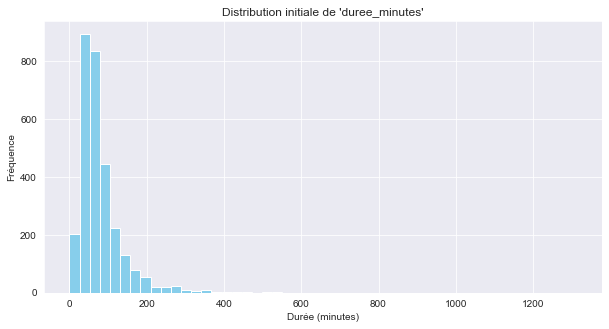

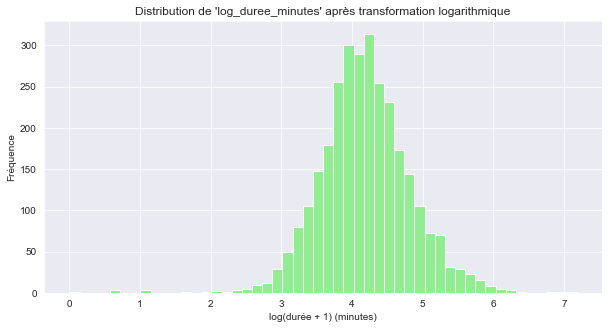

In [13]:
plt.figure(figsize=(10, 5))
doubs_data['duree_minutes'].hist(bins=50, color='skyblue')
plt.title("Distribution initiale de 'duree_minutes'")
plt.xlabel("Durée (minutes)")
plt.ylabel("Fréquence")
plt.show()

doubs_data['log_duree_minutes'] = np.log1p(doubs_data['duree_minutes'])

plt.figure(figsize=(10, 5))
doubs_data['log_duree_minutes'].hist(bins=50, color='lightgreen')
plt.title("Distribution de 'log_duree_minutes' après transformation logarithmique")
plt.xlabel("log(durée + 1) (minutes)")
plt.ylabel("Fréquence")
plt.show()

In [14]:
features = ['centroid_lon', 'centroid_lat', 'hour_sin', 'hour_cos',
            'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']

target = 'log_duree_minutes'

X = doubs_data[features]
y = doubs_data[target]

print(X.head())

   centroid_lon  centroid_lat      hour_sin  hour_cos  month_sin  month_cos  \
0      6.233937     46.892889 -5.000000e-01 -0.866025  -0.866025        0.5   
1      5.807597     47.261659 -9.659258e-01  0.258819  -0.866025        0.5   
2      5.807597     47.261659 -9.659258e-01  0.258819  -0.866025        0.5   
3      5.894684     47.217820 -8.660254e-01  0.500000  -0.866025        0.5   
4      6.319047     46.755896  1.224647e-16 -1.000000  -0.866025        0.5   

   weekday_sin  weekday_cos  
0     0.433884    -0.900969  
1    -0.433884    -0.900969  
2    -0.974928    -0.222521  
3    -0.974928    -0.222521  
4    -0.781831     0.623490  


In [15]:
scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print(X_scaled_df.head())

   centroid_lon  centroid_lat  hour_sin  hour_cos  month_sin  month_cos  \
0     -0.170256     -1.160194  0.292893 -0.628626  -0.267949   1.154701   
1     -0.761608      0.038431 -0.366025  0.535898  -0.267949   1.154701   
2     -0.761608      0.038431 -0.366025  0.535898  -0.267949   1.154701   
3     -0.640813     -0.104060 -0.224745  0.785587  -0.267949   1.154701   
4     -0.052204     -1.605466  1.000000 -0.767327  -0.267949   1.154701   

   weekday_sin   weekday_cos  
0     0.277479 -4.450419e-01  
1    -0.277479 -4.450419e-01  
2    -0.623490 -1.638616e-16  
3    -0.623490 -1.638616e-16  
4    -0.500000  5.549581e-01  


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Ensemble d'entraînement : {X_train.shape}, {y_train.shape}")
print(f"Ensemble de test : {X_test.shape}, {y_test.shape}")

Ensemble d'entraînement : (2372, 8), (2372,)
Ensemble de test : (593, 8), (593,)


In [17]:
decision_tree = DecisionTreeRegressor(random_state=42)
random_forest = RandomForestRegressor(random_state=42)

decision_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)

y_pred_tree = decision_tree.predict(X_test)
y_pred_forest = random_forest.predict(X_test)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
mae_forest = mean_absolute_error(y_test, y_pred_forest)

print(f"DecisionTree - MAE : {mae_tree}")
print(f"RandomForest - MAE : {mae_forest}")

rmse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_forest = mean_squared_error(y_test, y_pred_forest)

print(f"DecisionTree - RMSE : {rmse_tree}")
print(f"RandomForest - RMSE : {rmse_forest}")

DecisionTree - MAE : 0.6233920743322838
RandomForest - MAE : 0.44317273933544493
DecisionTree - RMSE : 0.6559453940130995
RandomForest - RMSE : 0.34356780263460057


In [18]:
param_grid_tree = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
}

param_grid_forest = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
}

grid_tree = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid_tree, scoring='neg_mean_absolute_error', cv=5)
grid_tree.fit(X_train, y_train)

grid_forest = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_forest, scoring='neg_mean_absolute_error', cv=5)
grid_forest.fit(X_train, y_train)

print("Best parameters for DecisionTree:", grid_tree.best_params_)
print("Best MAE for DecisionTree:", -grid_tree.best_score_)

print("Best parameters for RandomForest:", grid_forest.best_params_)
print("Best MAE for RandomForest:", -grid_forest.best_score_)

Best parameters for DecisionTree: {'max_depth': 5, 'min_samples_split': 10}
Best MAE for DecisionTree: 0.4432288863577578
Best parameters for RandomForest: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best MAE for RandomForest: 0.4247713185234884


In [19]:
best_tree = grid_tree.best_estimator_
best_forest = grid_forest.best_estimator_

y_pred_tree_best = best_tree.predict(X_test)
y_pred_forest_best = best_forest.predict(X_test)

mae_tree_best = mean_absolute_error(y_test, y_pred_tree_best)
mae_forest_best = mean_absolute_error(y_test, y_pred_forest_best)

rmse_tree_best = mean_squared_error(y_test, y_pred_tree_best)
rmse_forest_best = mean_squared_error(y_test, y_pred_forest_best)

print(f"Optimized DecisionTree - MAE: {mae_tree_best}, RMSE: {rmse_tree_best}")
print(f"Optimized RandomForest - MAE: {mae_forest_best}, RMSE: {rmse_forest_best}")

Optimized DecisionTree - MAE: 0.45632335254461215, RMSE: 0.3679230304593772
Optimized RandomForest - MAE: 0.4323080619163617, RMSE: 0.3350263506306209


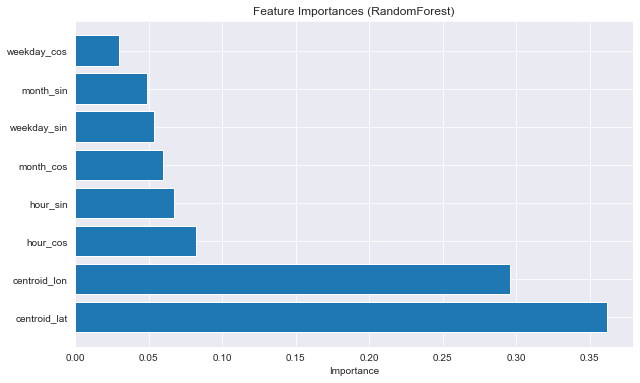

In [20]:
original_features = ['centroid_lon', 'centroid_lat']
cyclic_features = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']
feature_names = original_features + cyclic_features

importances = best_forest.feature_importances_
sorted_indices = importances.argsort()[::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[sorted_indices], align='center')
plt.yticks(range(len(importances)), [feature_names[i] for i in sorted_indices])
plt.xlabel('Importance')
plt.title('Feature Importances (RandomForest)')
plt.show()